In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [3]:
train=pd.read_csv('train.csv')

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

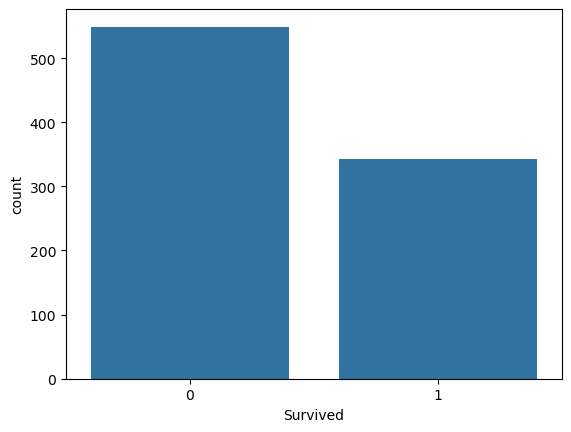

In [9]:
sns.countplot(x='Survived', data= train)
plt.show()

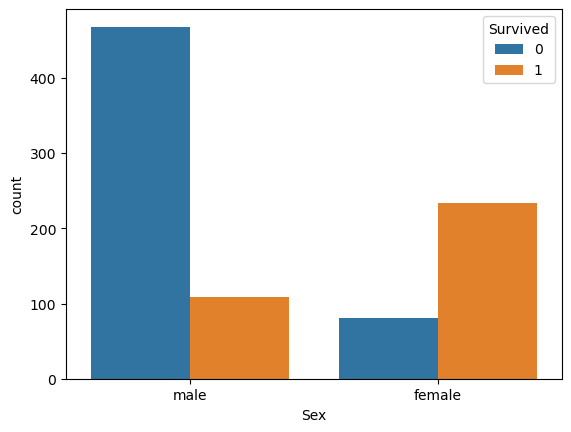

In [10]:
sns.countplot(x='Sex',hue='Survived',data=train)
plt.show()

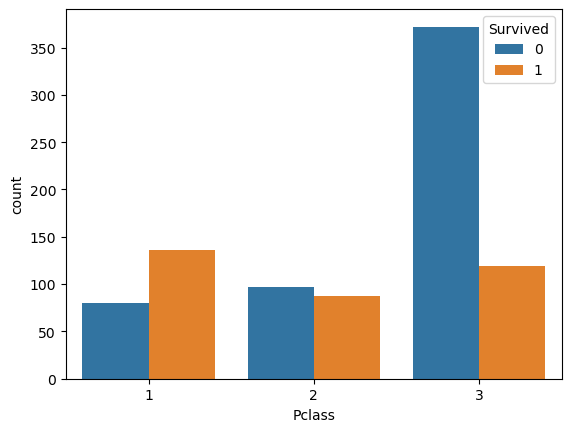

In [11]:
sns.countplot(x='Pclass',hue='Survived',data=train)
plt.show()

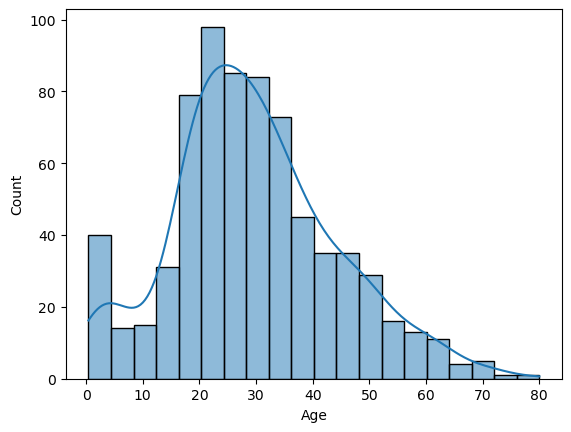

In [12]:
sns.histplot(train['Age'],kde=True)
plt.show()

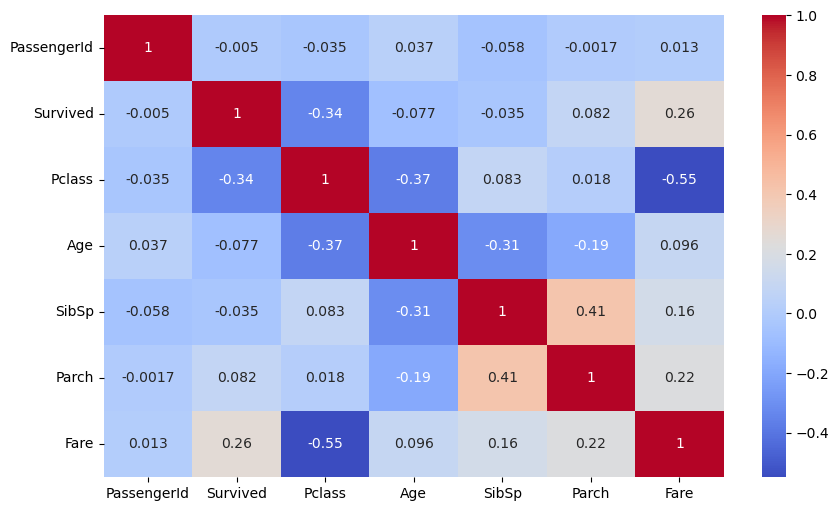

In [13]:
numeric_data=train.select_dtypes(include=['number'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(),annot=True,cmap='coolwarm')
plt.show()

In [14]:
train['Age']=train['Age'].fillna(train['Age'].median())

In [15]:
train['Embarked'] = train['Embarked'].fillna(
    train['Embarked'].mode()[0]
)

In [16]:
print(train['Embarked'].isnull().sum())

0


In [17]:
train.drop('Cabin',axis=1,inplace=True)

In [18]:
train['FamilySize']=(train['SibSp']+train['Parch']+1)

In [19]:
train['IsAlone']=np.where(train['FamilySize']==1,1,0)

In [20]:
train['Sex']=train['Sex'].map({
    'male':0,
    'female':1
})

In [21]:
train['Embarked'] = train['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

In [22]:
X=train[['Pclass',
         'Sex',
         'Age',
         'SibSp',
         'Parch',
         'Fare',
         'Embarked',
         'FamilySize',
         'IsAlone']]

In [23]:
y=train['Survived']

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression Model

In [25]:
lr_model = LogisticRegression(
    max_iter=1000
)
lr_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [26]:
X.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64

In [27]:
X.dtypes

Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
dtype: object

Logistic Regression Prediction

In [28]:
lr_pred=lr_model.predict(X_test)

Logistic Regression Accuracy

In [29]:
print(
    'Logistic Regression Aaccuracy:',
    accuracy_score(y_test,lr_pred)
)

Logistic Regression Aaccuracy: 0.7988826815642458


Random Forest Model

In [30]:
rf_model=RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

Random Forest Prediction

In [31]:
rf_pred=rf_model.predict(X_test)

Random Forest Accuracy

In [32]:
print(
    'Random Forest Accuracy:',
    accuracy_score(y_test, rf_pred)
)

Random Forest Accuracy: 0.8156424581005587


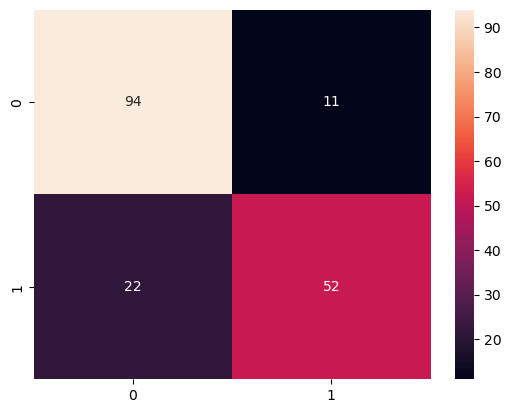

In [33]:
cm = confusion_matrix(
    y_test,
    rf_pred
)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.show()

In [34]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



In [35]:
importance = pd.DataFrame({
    'feature':X.columns,
    'Importance':rf_model.feature_importances_
})
importance= importance.sort_values(
    by = 'Importance',
    ascending=False
)
print(importance)

      feature  Importance
1         Sex    0.474736
5        Fare    0.147468
0      Pclass    0.134986
2         Age    0.109060
7  FamilySize    0.055791
3       SibSp    0.027314
6    Embarked    0.021048
4       Parch    0.018379
8     IsAlone    0.011219


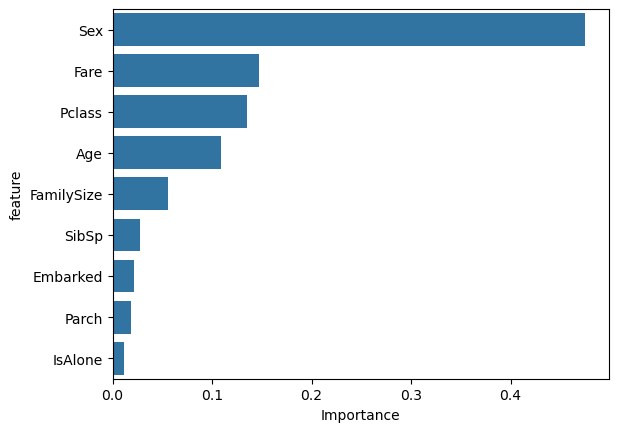

In [36]:
sns.barplot(
    x='Importance',
    y='feature',
    data=importance
)
plt.show()

In [37]:
import pickle
pickle.dump(
    rf_model,
    open('titanic_model.pkl','wb')
)